# Handwritten Digit Classification


## Introduction

**What is the goal of this lab?**

The goal of this lab is to get hands on experience evaluating ensemble ML techniques.

**Context**

Ensemble machine learning techniques combine multiple models to enhance prediction accuracy and reliability. Methods like bagging, boosting, and stacking work by aggregating the strengths of various models, reducing errors and improving generalization. These techniques are particularly useful when a single model might underperform, as the ensemble can make better, more balanced predictions by combining the outputs of different models.



### Data

This lab uses the Optical Recognition of Handwritten Digits data set 🔢. Each row represents an image of a hand written digit 0-9, each column is a pixel in the image. The values in the table represent the intensity of that pixel. This data set is used to classify the digit in each image for [optical character recognition](https://en.wikipedia.org/wiki/Optical_character_recognition).

In [ ]:
# Install package to download data sets from UCI ML Repo
!pip3 install -U ucimlrepo --quiet
from ucimlrepo import fetch_ucirepo

In [ ]:
# Get the data set
digits = fetch_ucirepo(name="Optical Recognition of Handwritten Digits")

In [ ]:
# Get raw data in a pandas.DataFrame format
digits_df = digits.data.original

In [ ]:
# Citation
print("Citation:\n", digits.metadata.additional_info.citation)

Citation:
 None


> _Alpaydin, E. and Kaynak, C. (1998). Optical Recognition of Handwritten
Digits._      
> _UCI Machine Learning Repository. https://doi.org/10.24432/C50P49._


In [ ]:
# More information
print("Check out this data set on the UCI ML Repository for more information:")
print(digits.metadata.repository_url)

Check out this data set on the UCI ML Repository for more information:
https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits


## Problem Statement

**Describe a use case or application that could utilize optical character recognition to classify hand written digits.**

_A use case can be in reading handwritten letters or numbers in note taking apps(Notability) and then converting them to text form when needed._


**Describe the differences between bagging and boosting.**

_In bagging, we train many models independently on a random dataset but in parallel, and then combine their results to get the final answer._
_Whereas, in boosting we train models sequentially and each model depends on the previous one tries to fix the mistakes made by the previous one._


**Describe the similarities and differences between Adaboost and gradient boosting.**

_AdaBoost and Gradient boosting build models in a sequential order and then fix mistakes or errors made by previous ones._
_AdaBoost focuses on giving more weight to misclassified samples, while gradient boosting uses errors of the previous model to make improved predictions_


## Exploratory Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Inspection

Print out the following details about the data:
- The first 5 rows of the data set
- Number of rows and columns
- Data type of each column
- Number of null values (or not-null values) in each column
- General statistics of each numeric column (min, max, mean, standard deviation)

---

**Hints**

- [`pandas.DataFrame.head()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)
- [`pandas.DataFrame.info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html)
- [`pandas.DataFrame.describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)

In [ ]:
print(digits_df.head(5))
print(digits_df.shape)
print(digits_df.dtypes)
print(digits_df.isnull().sum())
print(digits_df.describe())

   Attribute1  Attribute2  Attribute3  Attribute4  Attribute5  Attribute6  \
0           0           1           6          15          12           1   
1           0           0          10          16           6           0   
2           0           0           8          15          16          13   
3           0           0           0           3          11          16   
4           0           0           5          14           4           0   

   Attribute7  Attribute8  Attribute9  Attribute10  ...  Attribute56  \
0           0           0           0            7  ...            0   
1           0           0           0            7  ...            0   
2           0           0           0            1  ...            0   
3           0           0           0            0  ...            0   
4           0           0           0            0  ...            0   

   Attribute57  Attribute58  Attribute59  Attribute60  Attribute61  \
0            0            0       

### Data cleaning

No data cleaning for this lab. The data set is already clean 😀.

### Data Visualization and Statistics

Count the number of instances of each digit. This is the `"class"` column of the data frame.

---
**Hints**

- [`pandas.Series.value_counts()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html)
- [`pandas.Series.sort_index()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.sort_index.html)

In [ ]:
print(digits_df['class'].value_counts().sort_index())

class
0    554
1    571
2    557
3    572
4    568
5    558
6    558
7    566
8    554
9    562
Name: count, dtype: int64


Visualize the "average" of each digit.
- Group by the the `"class"` columns
- Take the `.mean()` of every other column for each class.
- The resulting data frame should have 10 rows, 1 for each digit.
- For each row, `.reshape()` the values to be an 8 x 8 grid.
- Use `matplotlib.pyplot.imshow(cmap='gray')` to print out the image of the "average" of each digit in black and white.


---
**Hints**

*Getting the pixel averages*
- [`pandas.DataFrame.groupby()`]()
- [`pandas.DataFrame.mean()`]()

*Reshaping a row into an image*
- [`pandas.Series.drop()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.drop.html) to remove the class value
- [`pandas.Series.values`](https://pandas.pydata.org/docs/reference/api/pandas.Series.values.html) to convert to a numpy array
- [`numpy.ndarray.reshape()`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.reshape.html) to reshape the array into an 8x8 matrix

*Plotting the image pixel values*
- [`matplotlib.pyplot.imshow()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html)

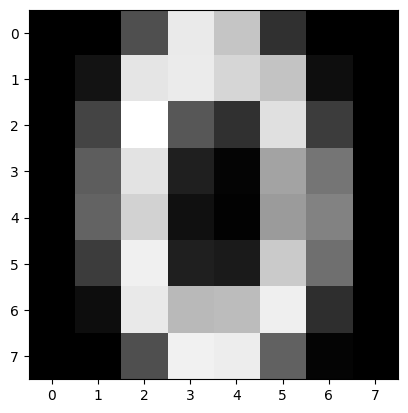

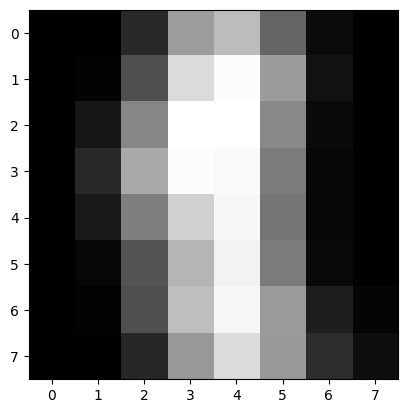

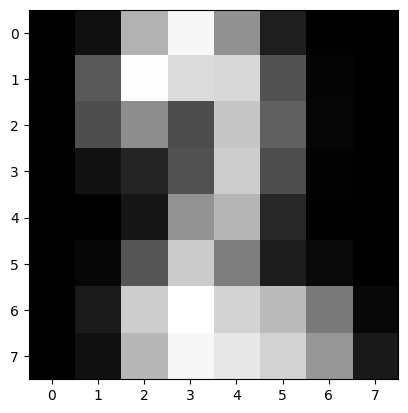

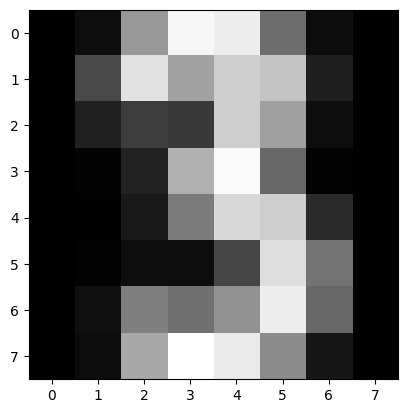

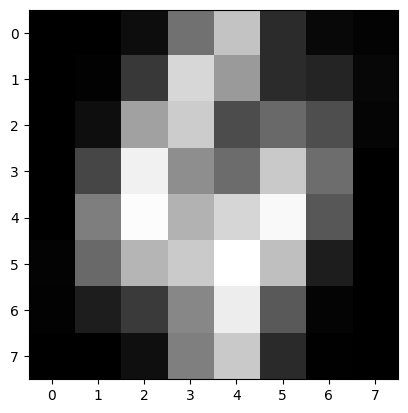

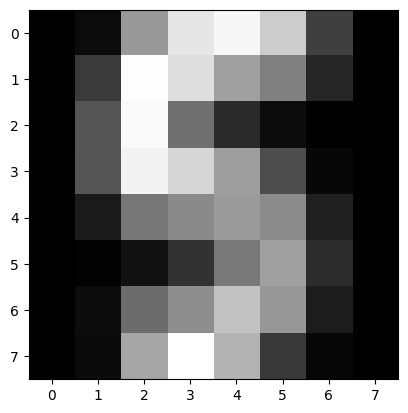

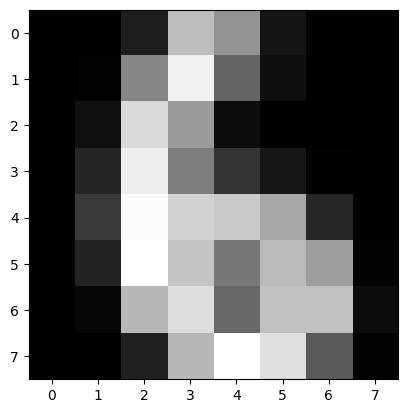

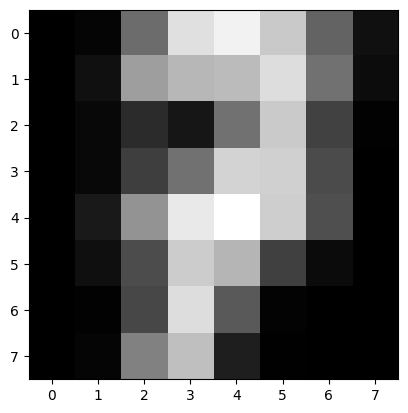

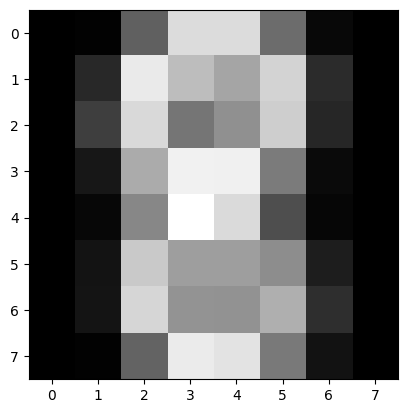

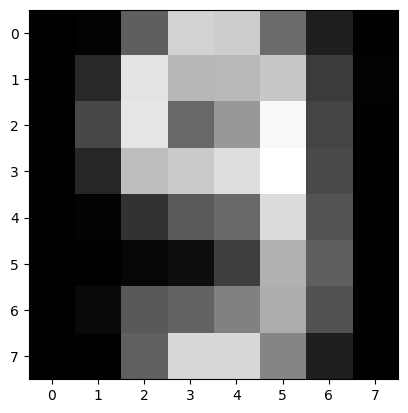

      Attribute1  Attribute2  Attribute3  Attribute4  Attribute5  Attribute6  \
0              0           1           6          15          12           1   
1              0           0          10          16           6           0   
2              0           0           8          15          16          13   
3              0           0           0           3          11          16   
4              0           0           5          14           4           0   
...          ...         ...         ...         ...         ...         ...   
5615           0           0           4          10          13           6   
5616           0           0           6          16          13          11   
5617           0           0           1          11          15           1   
5618           0           0           2          10           7           0   
5619           0           0          10          14           8           1   

      Attribute7  Attribute8  Attribute

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mean = digits_df.groupby('class').mean()

for i in range(10):
    image = mean.loc[i].values.reshape(8, 8)
    plt.imshow(image, cmap='gray')


    plt.show()

print(digits_df)


Run a principle component analysis with 5 components on the data set. Visualize the scatter plots and distributions of the 5 components with a Seaborn pairplot with each class as a different color (`hue='class'`).

---
**Hints**

- [`sklearn.decomposition.PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
- [`seaborn.pairplot()`](https://seaborn.pydata.org/generated/seaborn.pairplot.html)


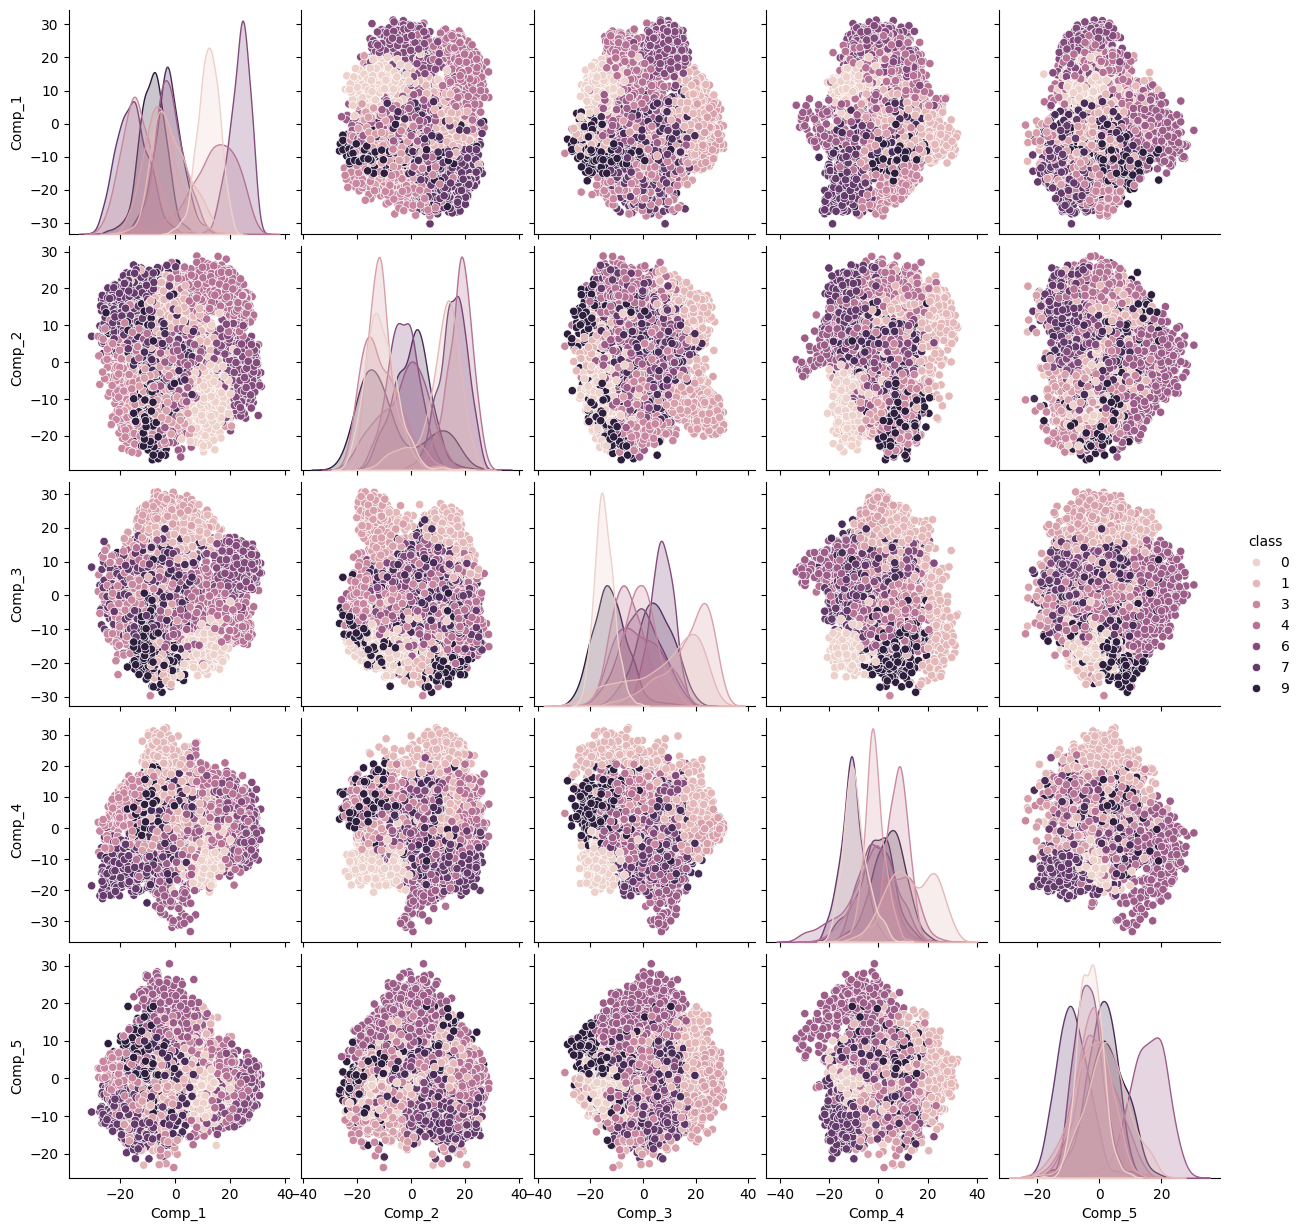

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

X = digits_df.drop('class', axis=1)
y = digits_df['class']

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(data=X_pca, columns=['Comp_1', 'Comp_2', 'Comp_3', 'Comp_4', 'Comp_5'])
pca_df['class'] = y

sns.pairplot(pca_df, hue='class')
plt.show()

## Models

Split the rows of the data set into 2 groups: 80% training -  & 20% testing.

Also separate the feature variables (X) from the target variable (y).

You should have 4 different objects with the data set: `X_train`, `X_test`, `y_train`, `y_test`.

---
**Hints**

- [`sklearn.model_selection.train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)


In [ ]:
from sklearn.model_selection import train_test_split

X = digits_df.drop('class', axis='columns')
y = digits_df['class']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(4496, 64)
(1124, 64)
(4496,)
(1124,)


Perform PCA on the *features* in the *training data set*. Save the top 5 components into a new DataFrame.

---
**Hints**
- [`sklearn.decomposition.PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train)

df_train_pca = pd.DataFrame(X_train_pca)
df_train_pca.columns = ['Comp_1', 'Comp_2', 'Comp_3', 'Comp_4', 'Comp_5']

print(df_train_pca.head())


      Comp_1     Comp_2     Comp_3     Comp_4    Comp_5
0  26.388032  12.735781  -9.383693   7.181406 -2.265164
1   7.090816  20.104532  -1.367422  -3.456562 -0.314028
2  18.265592  13.067750   3.228189  -7.630078 -0.703462
3  14.350337  22.892420 -12.766802  15.741644 -2.248016
4   3.466186  -0.023917   3.236366  -7.470034 -3.913687


K-fold cross validate (5-folds) 3 different ML Classification algorithms: K-nearest neigbors, support vector machines, and a decision tree. Use the 5 components from the PCA analysis as features to predict the number (`"class"`) of each hand written digit. Print out the average accuracy of all the folds for each algorithm.

---
**Hints**
- [`sklearn.neighbors.KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
- [`sklearn.svm.SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)
- [`sklearn.tree.DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
- [`sklearn.model_selection.cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)








In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

X = df_train_pca
y = y_train

knn = KNeighborsClassifier()
knn_score = cross_val_score(knn, X, y, cv=5)
print(f"KNN average accuracy: {knn_score.mean():11.6f}")

svm = SVC()
svm_score = cross_val_score(svm, X, y, cv=5)
print(f"SVM average accuracy: {svm_score.mean():11.6f}")

dt = DecisionTreeClassifier()
dt_score = cross_val_score(dt, X, y, cv=5)
print(f"D.Tree average accuracy: {dt_score.mean():.6f}")


KNN average accuracy:    0.921932
SVM average accuracy:    0.926605
D.Tree average accuracy: 0.862101


Repeat the same question, but instead of cross validating a single model from each algorithm, create a *bagging ensemble of 50 models* trained from each algothim and compare the average 5-fold cross validation accuracy of each ensemble of models for each algorithm.

---
**Hints**

- [`sklearn.ensemble.BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html)

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

X = df_train_pca
y = y_train

bag_knn = BaggingClassifier(KNeighborsClassifier(), n_estimators=50)
bag_knn_score = cross_val_score(bag_knn, X, y, cv=5)
print(f"Bagging KNN accuracy: {bag_knn_score.mean():11.6f}")

bag_svm = BaggingClassifier(SVC(), n_estimators=50)
bag_svm_score = cross_val_score(bag_svm, X, y, cv=5)
print(f"Bagging SVM accuracy: {bag_svm_score.mean():11.6f}")

bag_dt = BaggingClassifier(DecisionTreeClassifier(), n_estimators=50)
bag_dt_score = cross_val_score(bag_dt, X, y, cv=5)
print(f"Bagging D.Tree accuracy: {bag_dt_score.mean():.6f}")


Bagging KNN accuracy:    0.923711
Bagging SVM accuracy:    0.926382
Bagging D.Tree accuracy: 0.901467


Train a gradient boosted trees classifer to do the same tasks with the same features. Print out the average accuracy of a 5-fold cross validation.

---
**Hints**
- [`sklearn.ensemble.GradientBoostingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

X = df_train_pca
y = y_train

grad_boost = GradientBoostingClassifier()
grad_boost_score = cross_val_score(grad_boost, X,y, cv=5)

print(f"Gradient boosted tree accuracy: {grad_boost_score.mean():.6f}")



Gradient boosted tree accuracy: 0.903026


Create stacked ensemble of: K-nearest neighbors, support vector machine, and gradient boosted trees using the same input data. Perform 5-fold cross validation on the stacked ensemble of models and print out the average accuracy.

---
**Hints**

- [`sklearn.ensemble.StackingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html)

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

X = df_train_pca
y = y_train

estimators = [
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svm', SVC(kernel='linear',probability=True)),
    ('gb', GradientBoostingClassifier(n_estimators=30))
]

stacked_model = StackingClassifier(estimators=estimators, final_estimator=GradientBoostingClassifier(n_estimators=30))

stack_score = cross_val_score(stacked_model, X, y, cv=5)

print(f"Stacked Model average accuracy: {stack_score.mean():.6f}")


Stacked Model average accuracy: 0.916373


## Conclusion

**Which of the three algorithms was improved by baggging? For any that were not improved by bagging, why do you think that could be?**

_Decision Tree was improved the most from ~86.25% to ~89.74%, because averging many trees reduces variance and improves accuracy._
_KNN and SVM did not change much._

**Did stacking improve the performance to be better than the original models? In what cases would you expect stacking to work well?**

_Stacking did not improve performance much compared to the best single model (SVM, which was ~92.66%), as the stacked ensemble only reached about 91.7%. Stacking works well when the base models make errors, and then allowing the meta model to combine their strengths and correct individual mistakes._